In [19]:
from pathlib import Path
from itertools import chain

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from data_processing.loading.dataframe_loading import load_psd
from data_processing.arc_paths import get_parq_root, get_report_root, INPUT_DATA_FOLDER
from data_processing.processing.bimodal_fitting import (
    get_psd_energy_histogram, 
    scan_histogram_slices
)
from data_processing.reporting.plotting import plot_psd_histogram, plot_scatter
from data_processing.dataframe_validation import get_df_col, DataframeColumn

from scipy.signal import savgol_filter, find_peaks
from scipy.interpolate import UnivariateSpline

In [20]:
all_exp_details = {
    "ID-111": "Outside, with shield box",
    "ID-112": "Outside, no shield",
    "ID-113": "Inside, with thruster, no shield",
    "ID-114": "Inside, with thruster, with shield box",
    "ID-115": "Inside, with thruster, with shield box and wall"
}
experiment_spectra_paths = {exp_name:INPUT_DATA_FOLDER / exp_name / "processed_data/unfiltered/spectra/energy_spectrum_0.parquet" 
                            for exp_name in all_exp_details}

In [21]:
ncols = 2
nrows = 3
print(f"Column/row counts OK? {ncols * nrows >= len(all_exp_details)}")

Column/row counts OK? True


In [22]:
all_energy_spectra = {exp_name: pd.read_parquet(spectra_path) for exp_name, spectra_path in experiment_spectra_paths.items()}

In [23]:
smoothed_plot_data = {}
for exp_name, energy_spectrum in all_energy_spectra.items():
    bin_energy_array = energy_spectrum['bin_energy']
    energy_spectrum_smooth = savgol_filter(energy_spectrum['count'], 51, 9)
    energy_spectrum_spline = UnivariateSpline(bin_energy_array, energy_spectrum_smooth)
    energy_spectrum_spline_deriv = energy_spectrum_spline.derivative()
    peaks, _ = find_peaks(-energy_spectrum_spline_deriv(bin_energy_array), width=100, prominence=4)
    print(f"{exp_name}: Peaks at indices {peaks}, corresponding to energies {[bin_energy_array[peak] for peak in peaks]}")
    compton_edge = bin_energy_array[peaks[-1]]
    smoothed_plot_data[exp_name] = {
        "x": bin_energy_array,
        "y_raw": energy_spectrum['count'],
        "y_smoothed": energy_spectrum_smooth,
        "y": energy_spectrum_spline(bin_energy_array),
        "y_deriv": energy_spectrum_spline_deriv(bin_energy_array),
        "compton_edge": compton_edge,
        "exp_description": all_exp_details[exp_name]
    }

ID-111: Peaks at indices [2608 3018], corresponding to energies [1.82377, 2.10998]
ID-112: Peaks at indices [2289 3037], corresponding to energies [1.60108, 2.12324]
ID-113: Peaks at indices [ 498 2657], corresponding to energies [0.350841, 1.85797]
ID-114: Peaks at indices [2144], corresponding to energies [1.49986]
ID-115: Peaks at indices [3034], corresponding to energies [2.12768]


In [24]:
raw_plot_data = {}
for exp_name, energy_spectrum in all_energy_spectra.items():
    bin_energy_array = energy_spectrum['bin_energy']
    energy_spectrum_spline = UnivariateSpline(bin_energy_array, energy_spectrum['count'], s=16*len(bin_energy_array))
    energy_spectrum_spline_deriv = energy_spectrum_spline.derivative()
    peaks, _ = find_peaks(-energy_spectrum_spline_deriv(bin_energy_array), width=100, prominence=4)
    print(f"{exp_name}: Peaks at indices {peaks}, corresponding to energies {[bin_energy_array[peak] for peak in peaks]}")
    compton_edge = bin_energy_array[peaks[-1]]
    raw_plot_data[exp_name] = {
        "x": bin_energy_array,
        "y_raw": energy_spectrum['count'],
        "y": energy_spectrum_spline(bin_energy_array),
        "y_deriv": energy_spectrum_spline_deriv(bin_energy_array), 
        "compton_edge": compton_edge,
        "exp_description": all_exp_details[exp_name]
    }

ID-111: Peaks at indices [2993], corresponding to energies [2.09253]
ID-112: Peaks at indices [2585 2997], corresponding to energies [1.80771, 2.09532]
ID-113: Peaks at indices [ 498 2658], corresponding to energies [0.350841, 1.85867]
ID-114: Peaks at indices [2233], corresponding to energies [1.56199]
ID-115: Peaks at indices [3046], corresponding to energies [2.13608]


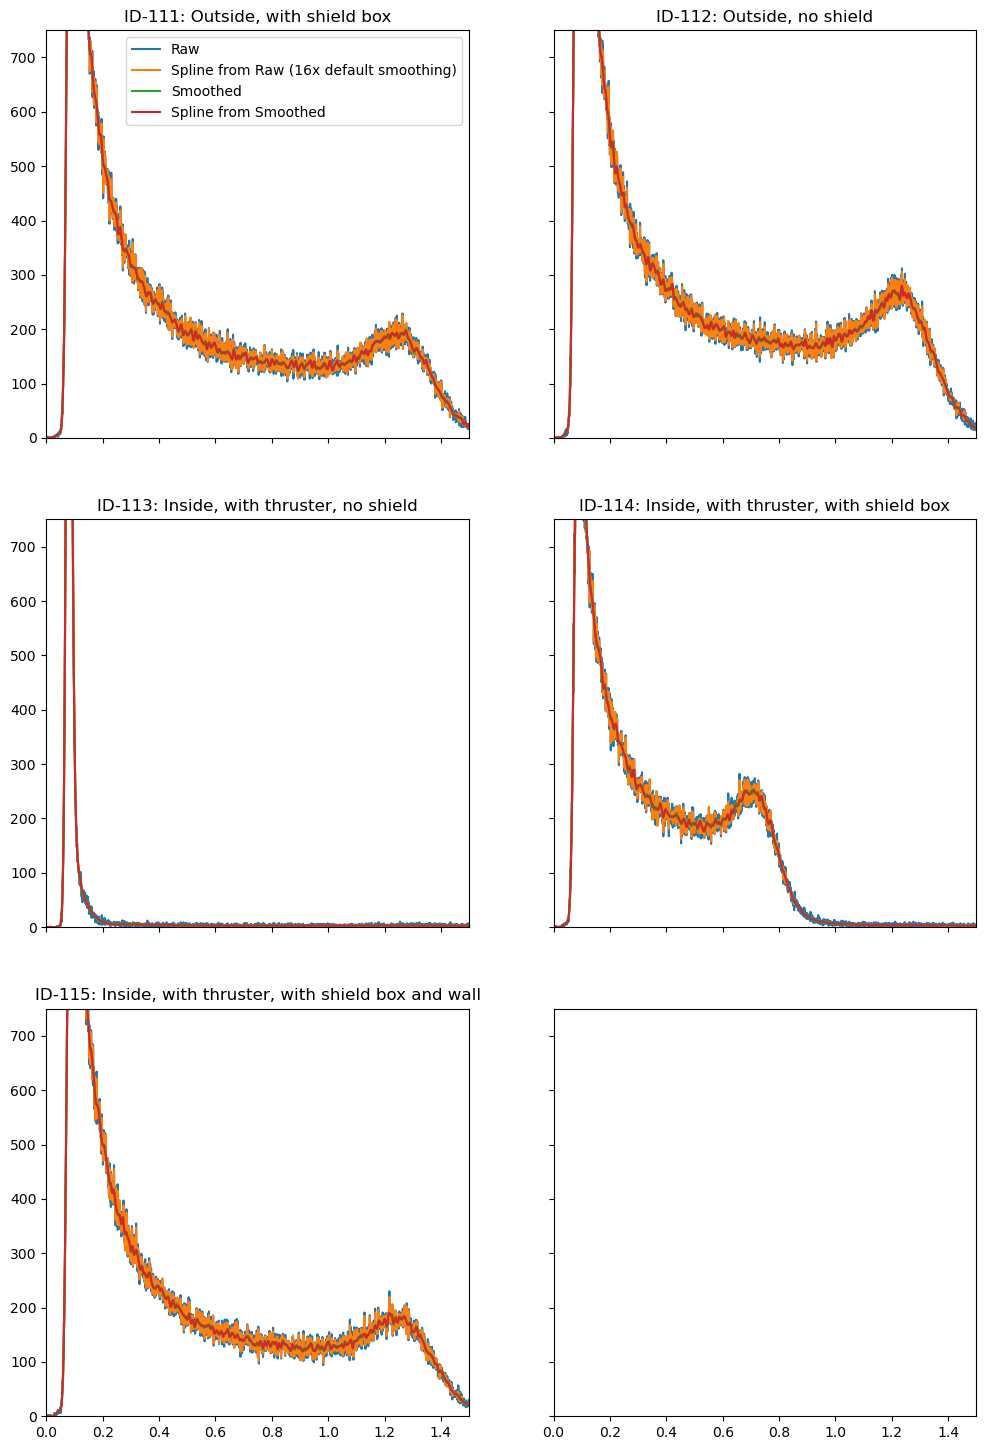

In [25]:
# comparing spline on smoothed vs raw data

# fig, ax = plt.subplots(figsize=(8,8))
subplot_side = 6
fig, axs = plt.subplots(nrows, ncols, sharex='all', sharey='all', figsize=(ncols*subplot_side,nrows*subplot_side))
all_axs = list(chain.from_iterable(axs))
for i, (exp_name, smoothed_plot_series) in enumerate(smoothed_plot_data.items()):
    raw_plot_series = raw_plot_data[exp_name]
    ax = all_axs[i]
    ax.set_title(f"{exp_name}: {smoothed_plot_series['exp_description']}")
    ax.plot(bin_energy_array, smoothed_plot_series['y_raw'], label="Raw")
    ax.plot(bin_energy_array, raw_plot_series['y'], label="Spline from Raw (16x default smoothing)")
    ax.plot(bin_energy_array, smoothed_plot_series['y_smoothed'], label="Smoothed")
    ax.plot(bin_energy_array, smoothed_plot_series['y'], label="Spline from Smoothed")
    ax.set_xlim(0.0, 1.5)
    ax.set_ylim(0, 750)
    if i == 0:
        ax.legend()

# No real shifts shown

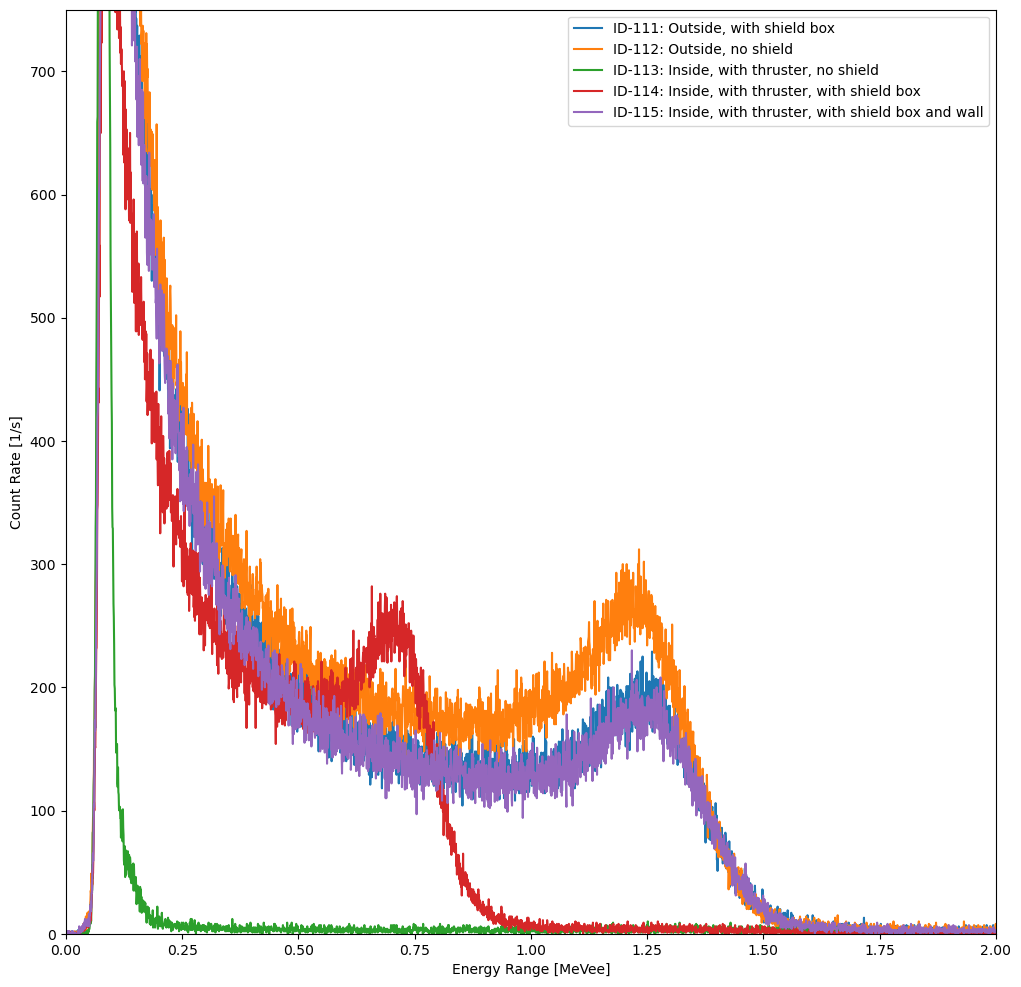

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

for i, (exp_name, plot_series) in enumerate(smoothed_plot_data.items()):
    ax.plot(plot_series['x'], plot_series['y_raw'], label=f"{exp_name}: {plot_series['exp_description']}")
    # compton_edge = plot_series['compton_edge']
    # ax.vlines([compton_edge], linestyle="dashed", ymin=0, ymax=50+i*20)
    # ax.text(compton_edge + 0.02, 50+i*20, f"{exp_name}: {compton_edge} MeVee")

# Add axis labels
ax.set_xlabel('Energy Range [MeVee]')
ax.set_ylabel('Count Rate [1/s]')

# Place the legend outside the plot to avoid overlap
ax.legend()
ax.set_xlim(0, 2)
ax.set_ylim(0, 750)


# Save the plot
plt.savefig('Magnetic_Field_Effect.png')

# Show the plot (optional)
plt.show()


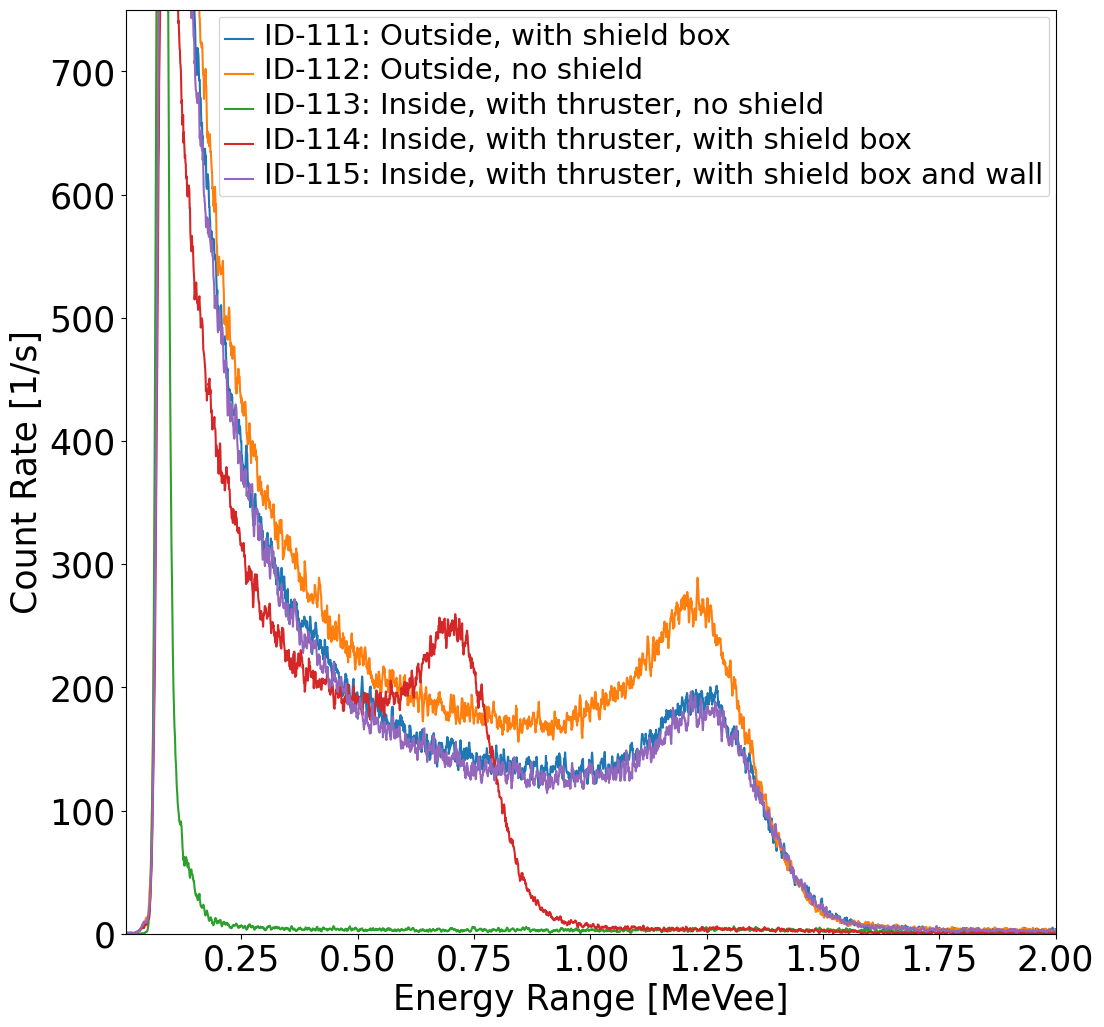

In [55]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 12))

for i, (exp_name, plot_series) in enumerate(smoothed_plot_data.items()):
    x = plot_series['x']
    y_raw = plot_series['y_raw']

    # Apply a simple moving average with a window size of 5 (adjust as needed)
    y_smoothed = np.convolve(y_raw, np.ones(5)/5, mode='valid')

    ax.plot(x[:len(y_smoothed)], y_smoothed, label=f"{exp_name}: {plot_series['exp_description']}")
    # compton_edge = plot_series['compton_edge']
    # ax.vlines([compton_edge], linestyle="dashed", ymin=0, ymax=50+i*20)
    # ax.text(compton_edge + 0.02, 50+i*20, f"{exp_name}: {compton_edge} MeVee")

# Add axis labels with increased font size
ax.set_xlabel('Energy Range [MeVee]', fontsize=25)
ax.set_ylabel('Count Rate [1/s]', fontsize=25)

# Increase tick label font size
ax.tick_params(axis='both', which='major', labelsize=25)  # Adjust the font size as needed

# Place the legend outside the plot to avoid overlap
ax.set_xlim(0.001, 2)  # Set x-axis limits to start from a small positive value
ax.set_ylim(0, 750)

# Access the legend and set font size
legend = ax.legend()
for text in legend.get_texts():
    text.set_fontsize(21)  # Adjust the font size as needed

# Save the plot
plt.savefig('Magnetic_Field_Effect.png')

# Show the plot (optional)
plt.show()


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

for i, (exp_name, plot_series) in enumerate(smoothed_plot_data.items()):
    ax.plot(plot_series['x'], plot_series['y_raw'], label=f"{exp_name}: {plot_series['exp_description']}")
    # compton_edge = plot_series['compton_edge']
    # ax.vlines([compton_edge], linestyle="dashed", ymin=0, ymax=50+i*20)
    # ax.text(compton_edge + 0.02, 50+i*20, f"{exp_name}: {compton_edge} MeVee")

# Add axis labels
ax.set_xlabel('Energy Range [MeVee]')
ax.set_ylabel('Count Rate [1/s]')

# Place the legend outside the plot to avoid overlap
ax.legend()
ax.set_xlim(0, 2)
ax.set_ylim(0, 750)


# Save the plot
plt.savefig('Magnetic_Field_Effect.png')

# Show the plot (optional)
plt.show()


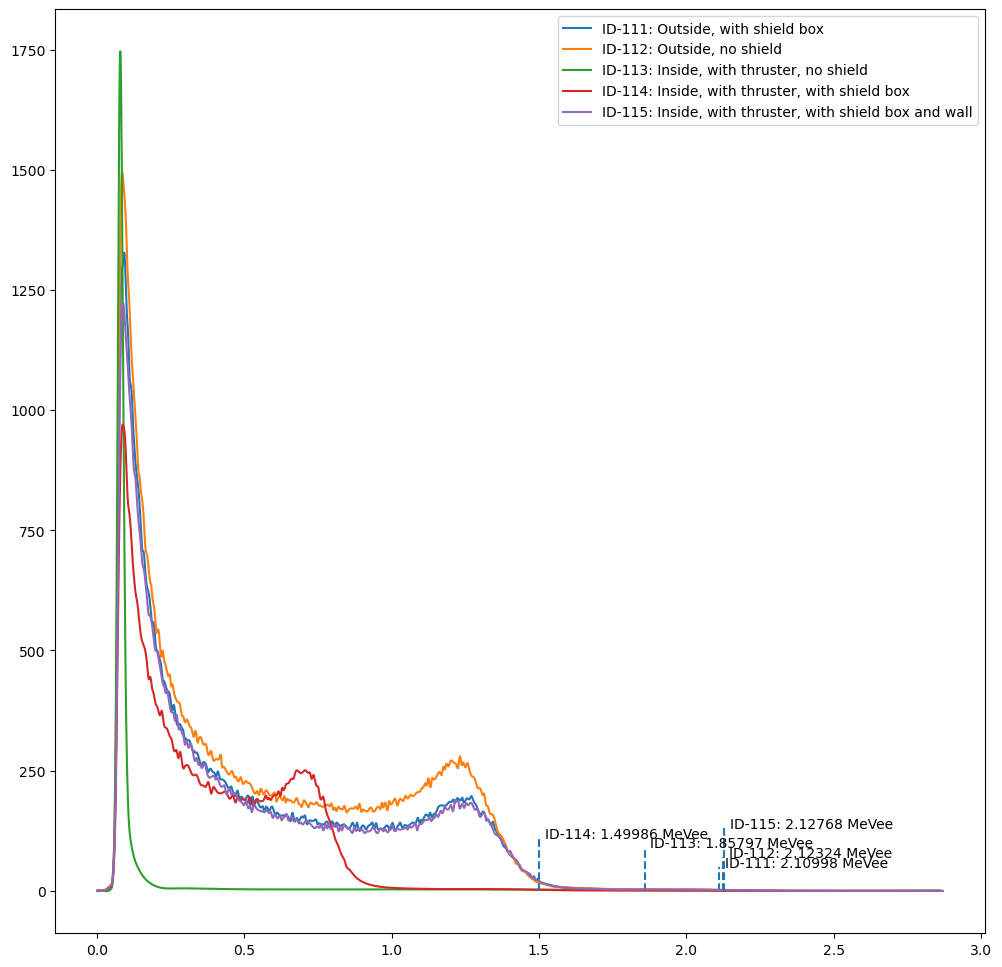

In [27]:
fig, ax = plt.subplots(figsize=(12,12))
for i, (exp_name, plot_series) in enumerate(smoothed_plot_data.items()):
    ax.plot(plot_series['x'], plot_series['y'], label=f"{exp_name}: {plot_series['exp_description']}")
    compton_edge = plot_series['compton_edge']
    ax.vlines([compton_edge], linestyle="dashed", ymin=0, ymax=50+i*20)
    ax.text(compton_edge + 0.02, 50+i*20, f"{exp_name}: {compton_edge} MeVee")
ax.legend()

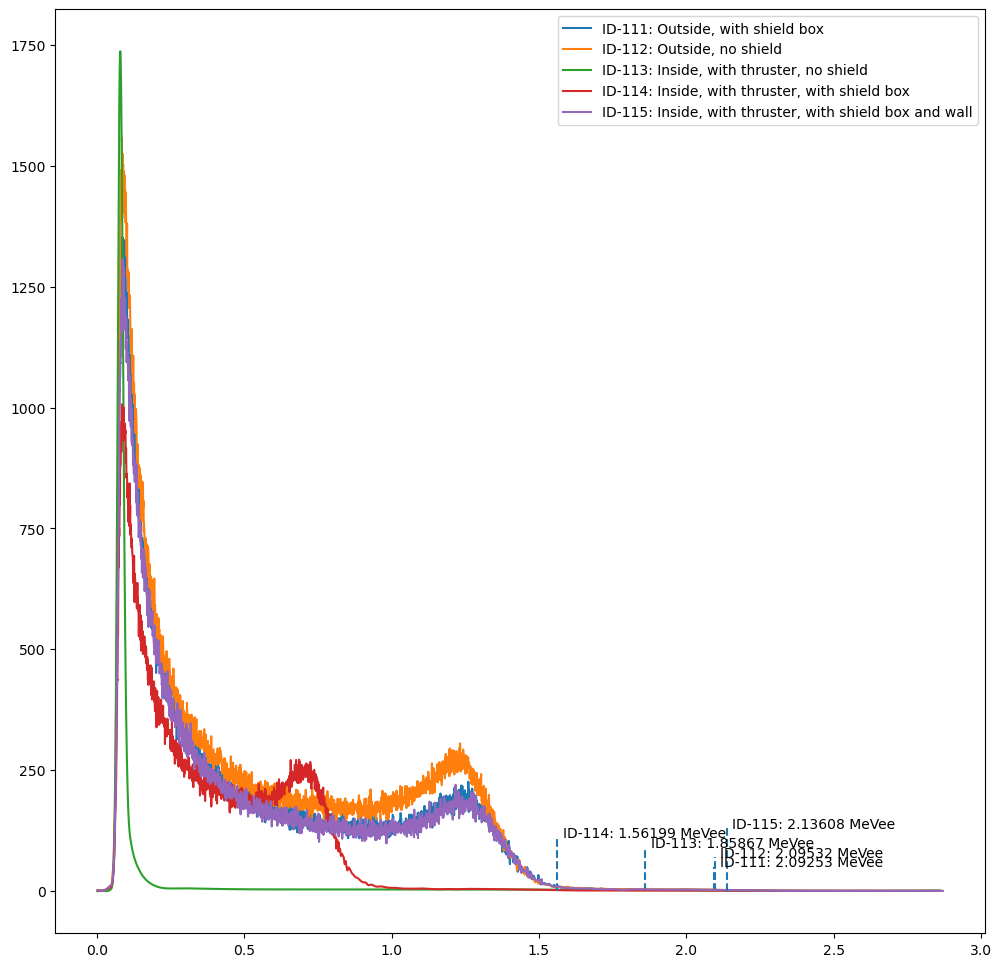

In [28]:
fig, ax = plt.subplots(figsize=(12,12))
for i, (exp_name, plot_series) in enumerate(raw_plot_data.items()):
    ax.plot(plot_series['x'], plot_series['y'], label=f"{exp_name}: {plot_series['exp_description']}")
    compton_edge = plot_series['compton_edge']
    ax.vlines([compton_edge], linestyle="dashed", ymin=0, ymax=50+i*20)
    ax.text(compton_edge + 0.02, 50+i*20, f"{exp_name}: {compton_edge} MeVee")
ax.legend()

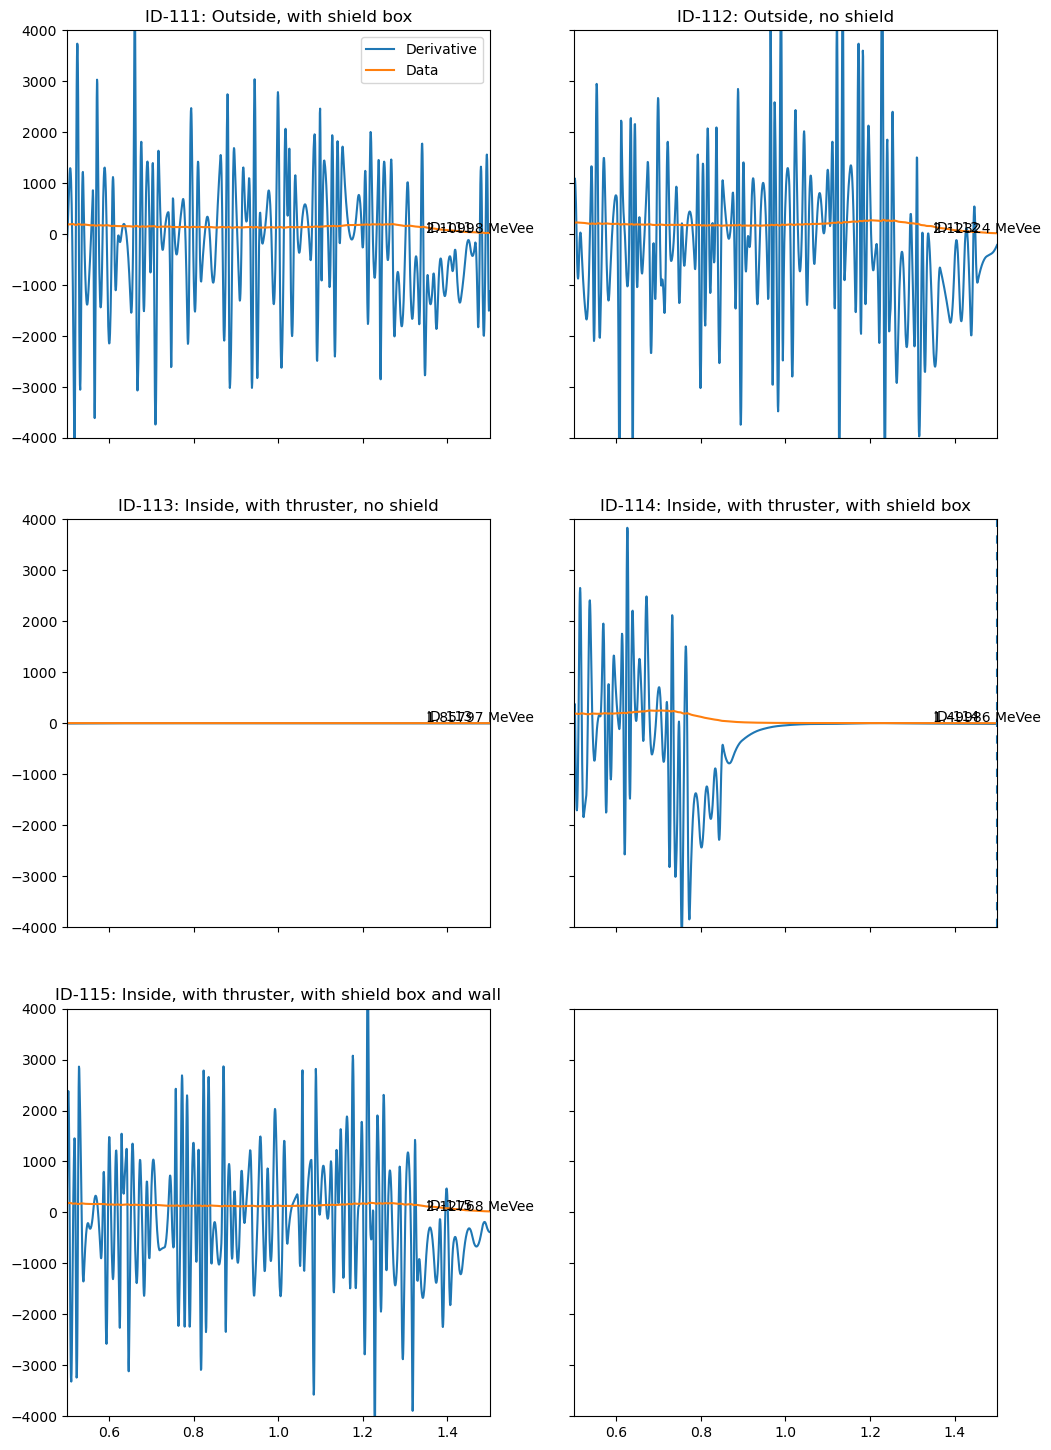

In [29]:
fig, axs = plt.subplots(nrows, ncols, sharex='all', sharey='all', figsize=(ncols*subplot_side,nrows*subplot_side))
all_axs = list(chain.from_iterable(axs))
for i, (exp_name, plot_series) in enumerate(smoothed_plot_data.items()):
    ax = all_axs[i]
    ax.set_title(f"{exp_name}: {plot_series['exp_description']}")
    ax.plot(plot_series['x'], plot_series['y_deriv'], label="Derivative")
    ax.plot(plot_series['x'], plot_series['y'], label="Data")
    compton_edge = plot_series['compton_edge']
    ax.axvline(compton_edge, ymin=0, ymax=1, dashes=(4,4))
    text_x = compton_edge + 0.02 if 1.0<compton_edge<1.45 else 1.35
    text_y = 50
    ax.text(text_x, text_y, f"{exp_name}")
    ax.text(text_x, text_y - 20, f"{compton_edge} MeVee")
    ax.set_ylim(-4000, 4000)
    ax.set_xlim(0.5, 1.5)
    if i == 0:
        ax.legend()

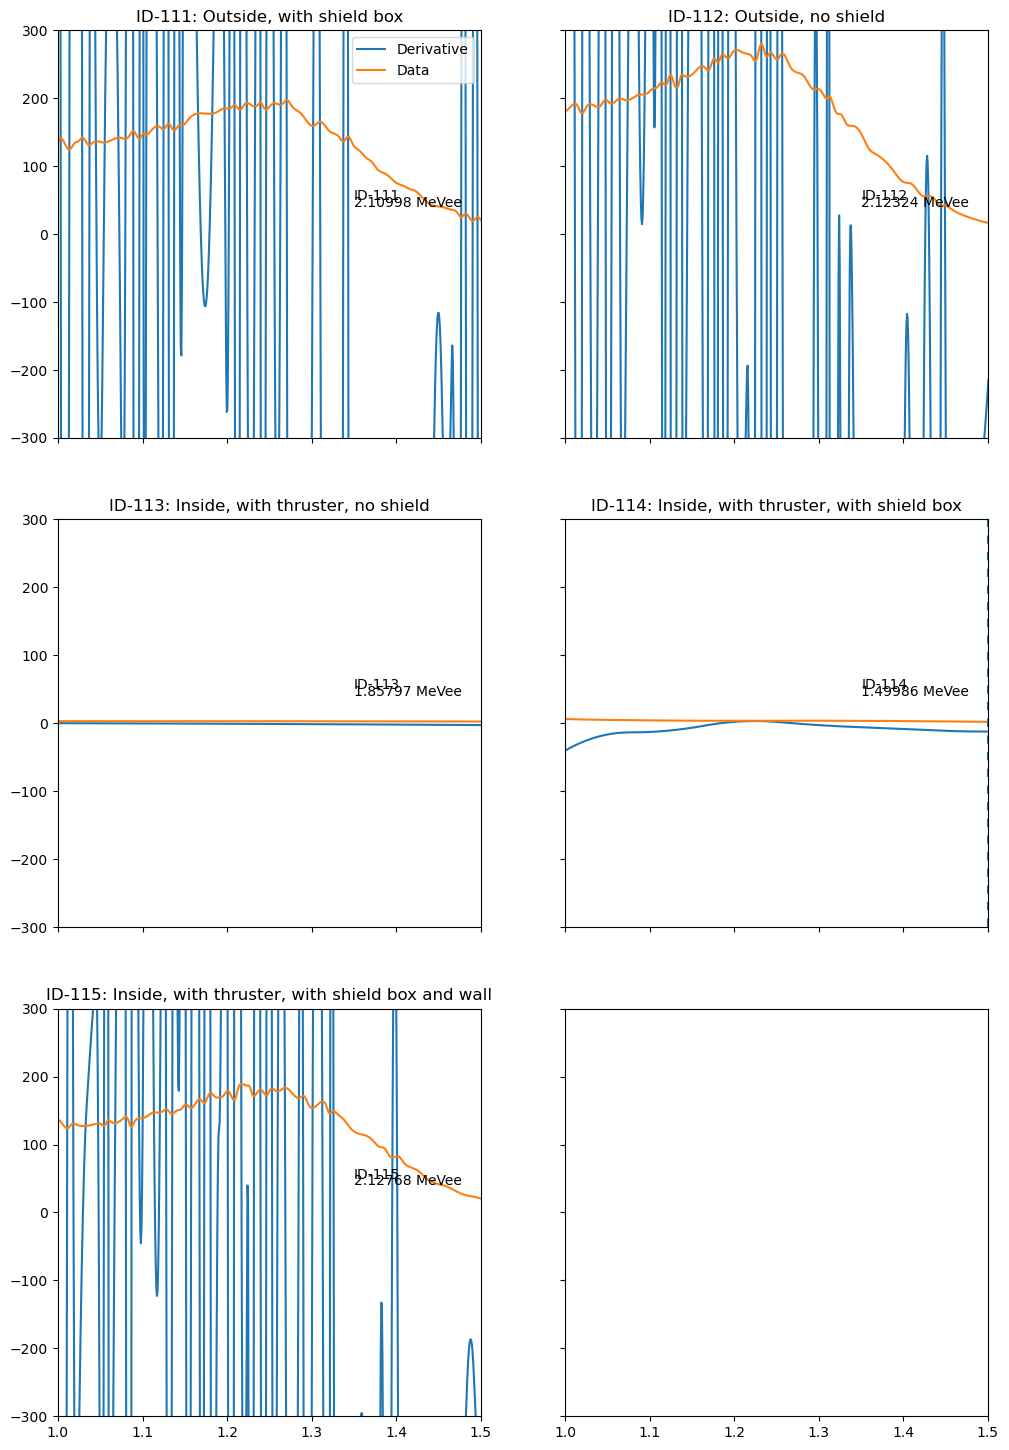

In [30]:
fig, axs = plt.subplots(nrows, ncols, sharex='all', sharey='all', figsize=(ncols*subplot_side,nrows*subplot_side))
all_axs = list(chain.from_iterable(axs))
for i, (exp_name, plot_series) in enumerate(smoothed_plot_data.items()):
    ax = all_axs[i]
    ax.set_title(f"{exp_name}: {plot_series['exp_description']}")
    ax.plot(plot_series['x'], plot_series['y_deriv'], label="Derivative")
    ax.plot(plot_series['x'], plot_series['y'], label="Data")
    compton_edge = plot_series['compton_edge']
    ax.axvline(compton_edge, ymin=0, ymax=1, dashes=(4,4))
    text_x = compton_edge + 0.02 if 1.0<compton_edge<1.45 else 1.35
    text_y = 50
    ax.text(text_x, text_y, f"{exp_name}")
    ax.text(text_x, text_y - 10, f"{compton_edge} MeVee")
    ax.set_ylim(-300, 300)
    ax.set_xlim(1.0, 1.5)
    if i == 0:
        ax.legend()